# NYC Taxi Trip Duration — Hồi quy với TabNet




 Bước 0 — Cài đặt & Import thư viện <a id='buoc0'></a>



In [1]:
# Cài đặt thư viện
!pip install pytorch-tabnet -q
print(' Cài đặt xong!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.1 MB/s eta 0:00:00
 Cài đặt xong!


In [2]:
# Import thư viện
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import os
warnings.filterwarnings('ignore')
# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# TabNet
from pytorch_tabnet.tab_model import TabNetRegressor
import torch
# Cài đặt hiển thị
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size']      = 12
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 20)


print(f'PyTorch version : {torch.__version__}')
print(f'GPU available   : {torch.cuda.is_available()}')
print(' Import thư viện thành công!')

PyTorch version : 2.11.0+cu128
GPU available   : True
 Import thư viện thành công!


---
##  Bước 1 — Tải & Khám sát dữ liệu ban đầu



In [3]:
# Upload file train.csv lên Colab
from google.colab import files
uploaded = files.upload()   # Chọn file train.csv từ máy tính
print(' Upload xong!')

Saving train.csv to train.csv
 Upload xong!


In [4]:

DATA_PATH = 'train.csv'
N_ROWS    = 500_000

print(f'Đọc {N_ROWS:,} dòng từ {DATA_PATH} ...')
df = pd.read_csv(DATA_PATH, nrows=N_ROWS)

print('\n' + '─' * 40)
print('THÔNG TIN TỔNG QUAN')
print('─' * 40)
print(f'Số dòng : {df.shape[0]:,}')
print(f'Số cột  : {df.shape[1]}')
df.head()

Đọc 500,000 dòng từ train.csv ...

────────────────────────────────────────
THÔNG TIN TỔNG QUAN
────────────────────────────────────────
Số dòng : 500,000
Số cột  : 11


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [5]:
# Kiểu dữ liệu
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  500000 non-null  object 
 1   vendor_id           500000 non-null  int64  
 2   pickup_datetime     500000 non-null  object 
 3   dropoff_datetime    500000 non-null  object 
 4   passenger_count     500000 non-null  int64  
 5   pickup_longitude    500000 non-null  float64
 6   pickup_latitude     500000 non-null  float64
 7   dropoff_longitude   500000 non-null  float64
 8   dropoff_latitude    500000 non-null  float64
 9   store_and_fwd_flag  500000 non-null  object 
 10  trip_duration       500000 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 42.0+ MB


In [6]:
# Thống kê mô tả
df.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,5.000000e+05
mean,1.534454,1.661816,-73.973512,40.750986,-73.973375,40.751832,9.552178e+02
std,0.498812,1.310769,0.039528,0.034236,0.038877,0.035627,4.179752e+03
min,1.000000,0.000000,-77.896019,34.712234,-79.817978,32.181141,1.000000e+00
25%,1.000000,1.000000,-73.991882,40.737347,-73.991318,40.735957,3.970000e+02
50%,2.000000,1.000000,-73.981758,40.754139,-73.979729,40.754490,6.620000e+02
75%,2.000000,2.000000,-73.967285,40.768375,-73.962975,40.769814,1.075000e+03
max,2.000000,9.000000,-70.851616,51.881084,-70.851616,43.486885,1.939736e+06


In [7]:
# Thống kê biến mục tiêu
print(' Thống kê trip_duration (giây):')
print(df['trip_duration'].describe())
print(f'\nSkewness       : {df["trip_duration"].skew():.2f}  (>1 = rất lệch → cần log transform)')
print(f'Tỉ lệ > 1 giờ : {(df["trip_duration"] > 3600).mean()*100:.1f}%')
print(f'Tỉ lệ > 3 giờ : {(df["trip_duration"] > 10800).mean()*100:.2f}%')

 Thống kê trip_duration (giây):
count    5.000000e+05
mean     9.552178e+02
std      4.179752e+03
min      1.000000e+00
25%      3.970000e+02
50%      6.620000e+02
75%      1.075000e+03
max      1.939736e+06
Name: trip_duration, dtype: float64

Skewness       : 210.52  (>1 = rất lệch → cần log transform)
Tỉ lệ > 1 giờ : 0.8%
Tỉ lệ > 3 giờ : 0.14%


---
##  Bước 2 — Tiền xử lý dữ liệu (Preprocessing) <a id='buoc2'></a>

### 2.1 Kiểm tra Missing Values
1. Giống notebook gốc: kiểm tra từng cột, điền giá trị phù hợp
2. Dataset NYC Taxi thường không có missing — xác nhận và ghi nhận

In [8]:
# Kiểm tra missing values
missing     = df.isnull().sum()
missing_pct = missing / len(df) * 100
missing_df  = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct
}).sort_values('Missing Count', ascending=False)

print('Các cột có giá trị bị thiếu:')
if missing_df['Missing Count'].sum() > 0:
    print(missing_df[missing_df['Missing Count'] > 0])
else:
    print('   Không có missing values trong dataset này!')

Các cột có giá trị bị thiếu:
   Không có missing values trong dataset này!


### 2.2 Feature Engineering từ datetime & tọa độ GPS
1. Đây là bước quan trọng nhất: mô hình không thể học trực tiếp từ chuỗi 2016-03-14 17:24:55, nhưng có thể học từ giờ=17, is_rush_hour=True.

2. Haversine distance là khoảng cách đường chim bay giữa 2 điểm GPS — thường là feature quan trọng nhất.

In [9]:
# Parse datetime
df['pickup_datetime']  = pd.to_datetime(df['pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'])

# Features từ thời gian pickup
df['pickup_hour']      = df['pickup_datetime'].dt.hour          # 0-23
df['pickup_dayofweek'] = df['pickup_datetime'].dt.dayofweek     # 0=Thứ 2, 6=Chủ nhật
df['pickup_month']     = df['pickup_datetime'].dt.month         # 1-12
df['pickup_day']       = df['pickup_datetime'].dt.day           # 1-31
df['is_weekend']       = (df['pickup_dayofweek'] >= 5).astype(int)
df['is_rush_hour']     = df['pickup_hour'].isin([7,8,9,17,18,19]).astype(int)
df['is_night']         = df['pickup_hour'].isin([22,23,0,1,2,3,4,5]).astype(int)

print(' Features thời gian:', ['pickup_hour','pickup_dayofweek','pickup_month',
                                  'pickup_day','is_weekend','is_rush_hour','is_night'])

 Features thời gian: ['pickup_hour', 'pickup_dayofweek', 'pickup_month', 'pickup_day', 'is_weekend', 'is_rush_hour', 'is_night']


In [10]:
# Khoảng cách Haversine (km) — đường chim bay giữa pickup và dropoff
def haversine_km(lat1, lon1, lat2, lon2):
    R    = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a    = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

df['haversine_dist'] = haversine_km(
    df['pickup_latitude'],  df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)
df['delta_lat']      = df['dropoff_latitude']  - df['pickup_latitude']
df['delta_lon']      = df['dropoff_longitude'] - df['pickup_longitude']
df['manhattan_dist'] = np.abs(df['delta_lat']) + np.abs(df['delta_lon'])
df['direction']      = np.arctan2(df['delta_lat'], df['delta_lon'])

print(' Features tọa độ:', ['haversine_dist','manhattan_dist','delta_lat','delta_lon','direction'])
df[['haversine_dist','manhattan_dist','direction']].describe()

 Features tọa độ: ['haversine_dist', 'manhattan_dist', 'delta_lat', 'delta_lon', 'direction']


,haversine_dist,manhattan_dist,direction
count,500000.000000,500000.000000,500000.000000
mean,3.439590,0.045875,-0.226398
std,4.434849,0.059880,1.738930
min,0.000000,0.000000,-3.141501
25%,1.233599,0.016106,-1.990916
50%,2.096119,0.027412,0.035916
75%,3.874810,0.050507,1.058452
max,1240.908677,12.308044,3.141593


1. là biến haversine_dist dùng để đo khoảng cách đường chim bay ngắn nhất giữa điểm đón và điểm trả khách dựa trên bề mặt cong hình cầu của Trái Đất.

2. biến manhattan_dist dùng để tính toán quãng đường di chuyển theo các góc vuông ô cờ, mô phỏng cách xe taxi phải chạy thực tế qua các con phố giao nhau của New York thay vì bay thẳng, giúp phản ánh thời gian chạy xe sát với thực tế hơn.

3. hai biến delta_lat và delta_lon chỉ đơn thuần đo mức độ chênh lệch khoảng cách tuyến tính thuần túy theo chiều dọc vĩ độ và chiều ngang kinh độ.

4. biến direction thực hiện tính toán góc toán học để xác định xe đang di chuyển về hướng nào như Đông, Tây, Nam, Bắc, giúp mô hình nhận diện được các quy luật giao thông hoặc tắc đường theo dòng luồng di chuyển.

### 2.3 Xử lý Outliers (IQR × 3.0)
1.  Dùng factor=3.0 (rộng hơn 1.5 thông thường) → chỉ loại outliers cực đoan.  
2.  Hàm remove_outliers_iqr lấy trực tiếp từ notebook gốc.

In [11]:
def remove_outliers_iqr(df, col, factor=3.0):
    """Loại bỏ outliers cực đoan bằng IQR — giống notebook gốc."""
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR    = Q3 - Q1
    lower  = Q1 - factor * IQR
    upper  = Q3 + factor * IQR
    before = len(df)
    df     = df[(df[col] >= lower) & (df[col] <= upper)]
    print(f'  {col:20s}: xóa {before - len(df):,} dòng → còn {len(df):,}')
    return df

print('Xử lý outliers:')
df_clean = df.copy()
df_clean = remove_outliers_iqr(df_clean, 'trip_duration')
df_clean = remove_outliers_iqr(df_clean, 'haversine_dist')

# Loại bỏ dòng vô lý
before   = len(df_clean)
df_clean = df_clean[df_clean['passenger_count'] > 0]
df_clean = df_clean[df_clean['trip_duration'] > 10]
df_clean = df_clean[~((df_clean['haversine_dist'] < 0.01) & (df_clean['trip_duration'] > 300))]
print(f'  Dòng vô lý          : xóa {before - len(df_clean):,} dòng')
print(f'\nTổng sau xử lý       : {len(df_clean):,} dòng (từ {len(df):,} ban đầu)')
print(' Đã xử lý xong Outliers!')

Xử lý outliers:
  trip_duration       : xóa 7,148 dòng → còn 492,852
  haversine_dist      : xóa 18,488 dòng → còn 474,364
  Dòng vô lý          : xóa 1,887 dòng

Tổng sau xử lý       : 472,477 dòng (từ 500,000 ban đầu)
 Đã xử lý xong Outliers!


### 2.4 Log-transform biến mục tiêu
> trip_duration rất skewed (đuôi dài bên phải).  
> log1p(x) = log(1+x) giúp phân phối gần chuẩn hơn → mô hình hội tụ tốt hơn.

In [12]:
df_clean['log_trip_duration'] = np.log1p(df_clean['trip_duration'])

print(' Log-transform biến mục tiêu:')
print(f'  Skewness trước log : {df_clean["trip_duration"].skew():.2f}')
print(f'  Skewness sau log   : {df_clean["log_trip_duration"].skew():.2f}  (gần 0 hơn = tốt hơn)')
print(' Hoàn tất log-transform!')

 Log-transform biến mục tiêu:
  Skewness trước log : 1.30
  Skewness sau log   : -0.59  (gần 0 hơn = tốt hơn)
 Hoàn tất log-transform!


### 2.5 Label Encoding
1.  TabNet yêu cầu categorical features phải là integer(Label Encoded).  
2.  Numerical features giữ nguyên dạng float.

In [13]:
# Phân loại cột
cat_cols_raw = ['store_and_fwd_flag']
num_cols_raw = [
    'vendor_id', 'passenger_count',
    'pickup_longitude', 'pickup_latitude',
    'dropoff_longitude', 'dropoff_latitude',
    'pickup_hour', 'pickup_dayofweek', 'pickup_month', 'pickup_day',
    'is_weekend', 'is_rush_hour', 'is_night',
    'haversine_dist', 'manhattan_dist', 'delta_lat', 'delta_lon', 'direction'
]

df_encoded     = df_clean.copy()
label_encoders = {}

for col in cat_cols_raw:
    le                  = LabelEncoder()
    df_encoded[col]     = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le
    print(f'  {col}: {le.classes_} → {list(range(len(le.classes_)))}')

print(' Đã mã hóa xong categorical features!')

  store_and_fwd_flag: ['N' 'Y'] → [0, 1]
 Đã mã hóa xong categorical features!


### 2.6 Tách X / y — Loại bỏ Data Leakage
1. DATA LEAKAGE:dropoff_datetime chứa thông tin tương lai   
2. trong thực tế không biết giờ trả khách khi dự đoán → phải loại bỏ

In [14]:
LEAKAGE_COLS = ['dropoff_datetime', 'pickup_datetime', 'id',
                'trip_duration', 'log_trip_duration']

feature_cols = cat_cols_raw + num_cols_raw
feature_cols = [c for c in feature_cols if c in df_encoded.columns]

X = df_encoded[feature_cols].copy()
y = df_encoded['log_trip_duration'].values

print(f'Loại bỏ (leakage/id) : {LEAKAGE_COLS}')
print(f'Shape X              : {X.shape}')
print(f'Shape y              : {y.shape}')
print(f'Features dùng ({len(feature_cols)}): {feature_cols}')

Loại bỏ (leakage/id) : ['dropoff_datetime', 'pickup_datetime', 'id', 'trip_duration', 'log_trip_duration']
Shape X              : (472477, 19)
Shape y              : (472477,)
Features dùng (19): ['store_and_fwd_flag', 'vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'pickup_hour', 'pickup_dayofweek', 'pickup_month', 'pickup_day', 'is_weekend', 'is_rush_hour', 'is_night', 'haversine_dist', 'manhattan_dist', 'delta_lat', 'delta_lon', 'direction']


### 2.7 Chuẩn hóa dữ liệu (StandardScaler)
1. Chuẩn hóa numerical features vềmean=0, std=1
2. TabNet ít nhạy với scale hơn linear models, nhưng vẫn giúp tăng tốc hội tụ.

In [15]:
scaler        = StandardScaler()
num_cols_in_X = [c for c in num_cols_raw if c in X.columns]
X_scaled      = X.copy()
X_scaled[num_cols_in_X] = scaler.fit_transform(X[num_cols_in_X])

print(f' Đã chuẩn hóa {len(num_cols_in_X)} cột số!')
print(f'Shape cuối cùng của X: {X_scaled.shape}')
X_scaled.head(3)

 Đã chuẩn hóa 18 cột số!
Shape cuối cùng của X: (472477, 19)


,store_and_fwd_flag,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,pickup_hour,pickup_dayofweek,pickup_month,pickup_day,is_weekend,is_rush_hour,is_night,haversine_dist,manhattan_dist,delta_lat,delta_lon,direction
0,0,0.936862,-0.503297,-0.159042,0.610204,0.401924,0.439123,0.530679,-1.565836,-0.302418,-0.171128,-0.632795,1.490710,-0.528989,-0.556438,-0.542098,-0.102025,0.572778,0.074670
1,0,-1.067393,-0.503297,-0.095081,-0.592270,-0.855279,-0.776535,-2.130331,1.510300,1.484373,-0.401039,1.580290,-0.670821,1.890400,-0.418135,-0.317084,-0.312489,-0.782242,-1.460832
2,0,0.936862,-0.503297,-0.044024,0.446543,-1.066372,-1.519849,-0.408501,-1.053146,-1.493612,0.403649,-0.632795,-0.670821,-0.528989,1.645043,1.507925,-2.237501,-1.050364,-1.026888


### 2.8 Tách Train / Validation / Test (70% / 15% / 15%)
1. Giống notebook gốc: 2 bước split liên tiếp.  
2. Chuyển sang float32 vì TabNet/PyTorch yêu cầu.  
3. y phải có shape (N, 1) cho TabNetRegressor

In [17]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled, y, test_size=0.15, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=(0.15 / 0.85), random_state=42
)

# TabNet cần numpy float32
X_train_np = X_train.values.astype(np.float32)
X_val_np   = X_val.values.astype(np.float32)
X_test_np  = X_test.values.astype(np.float32)
y_train_np = y_train.astype(np.float32).reshape(-1, 1)  # shape (N,1)
y_val_np   = y_val.astype(np.float32).reshape(-1, 1)
y_test_np  = y_test.astype(np.float32).reshape(-1, 1)

print('Phân chia tập dữ liệu:')
print(f'  Train      : {X_train_np.shape[0]:,} dòng ({len(X_train)/len(X_scaled)*100:.0f}%)')
print(f'  Validation : {X_val_np.shape[0]:,}   dòng ({len(X_val)/len(X_scaled)*100:.0f}%)')
print(f'  Test       : {X_test_np.shape[0]:,}   dòng ({len(X_test)/len(X_scaled)*100:.0f}%)')


Phân chia tập dữ liệu:
  Train      : 330,733 dòng (70%)
  Validation : 70,872   dòng (15%)
  Test       : 70,872   dòng (15%)


---
##  Bước 3 — Phân tích dữ liệu khám phá (EDA)

### 3.1 Phân phối biến mục tiêu — trước & sau log transform

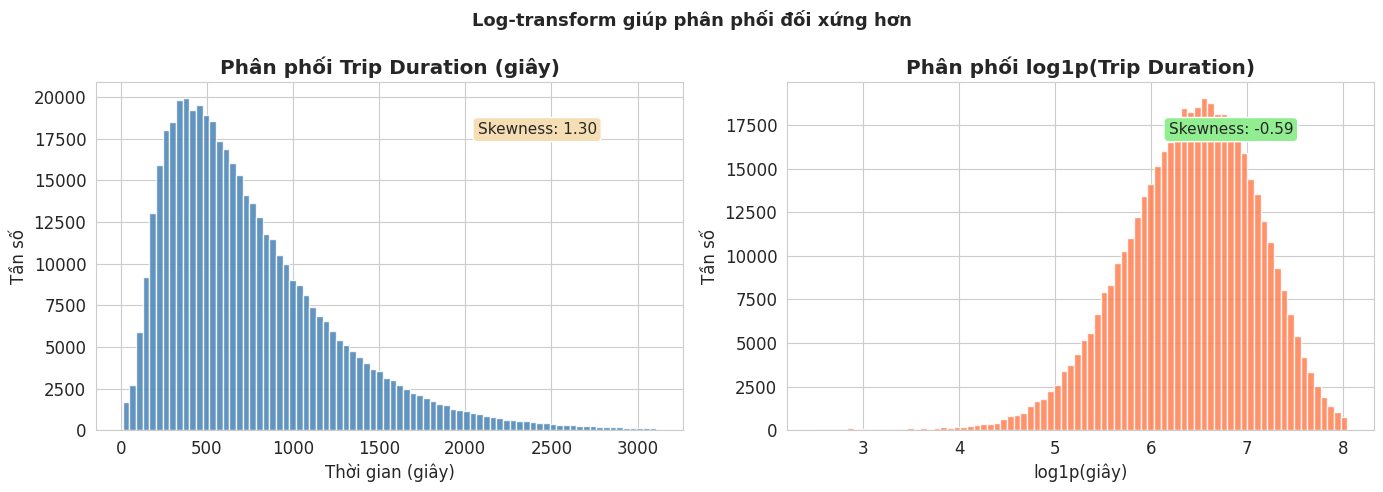

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['trip_duration'], bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Phân phối Trip Duration (giây)', fontweight='bold')
axes[0].set_xlabel('Thời gian (giây)'); axes[0].set_ylabel('Tần số')
axes[0].annotate(f'Skewness: {df_clean["trip_duration"].skew():.2f}',
                  xy=(0.65, 0.85), xycoords='axes fraction', fontsize=11,
                  bbox=dict(boxstyle='round', facecolor='wheat'))

axes[1].hist(df_clean['log_trip_duration'], bins=80, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('Phân phối log1p(Trip Duration)', fontweight='bold')
axes[1].set_xlabel('log1p(giây)'); axes[1].set_ylabel('Tần số')
axes[1].annotate(f'Skewness: {df_clean["log_trip_duration"].skew():.2f}',
                  xy=(0.65, 0.85), xycoords='axes fraction', fontsize=11,
                  bbox=dict(boxstyle='round', facecolor='lightgreen'))

plt.suptitle('Log-transform giúp phân phối đối xứng hơn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

1. hình dáng biểu đồ bên trái, cho thấy dữ liệu thời gian chuyến đi thô bị lệch phải , phân phối bị nén chặt ở vùng giá trị thấp và kéo một cái đuôi dài về phía các giá trị lớn

2. Skewness bên trái, đạt mức rất cao là mười một phẩy bảy mươi ba, thể hiện sự bất đối xứng nặng nề và dễ làm các mô hình hồi quy bị sai lệch dự đoán khi học tập.

3. biểu đồ bên phải cho thấy sau khi áp dụng phép biến đổi logarit (log1p), dữ liệu đã chuyển hoàn toàn sang dạng hình chuông đối xứng ổn định

4. là đánh giá chỉ số Skewness bên phải, đã giảm mạnh

### 3.2 Trip Duration theo giờ trong ngày & ngày trong tuần

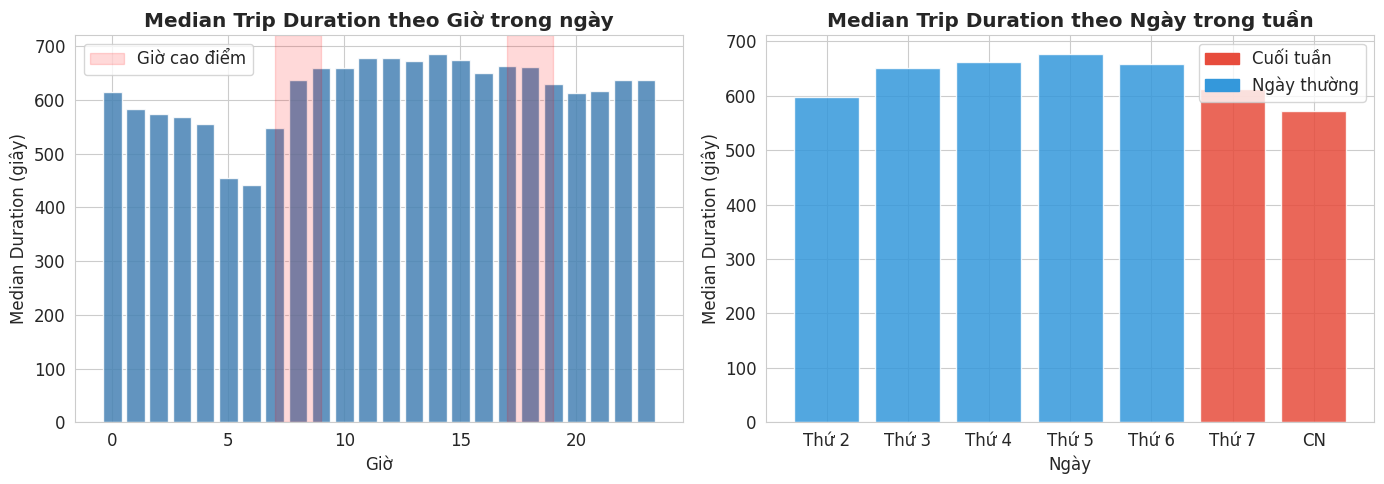

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hourly = df_clean.groupby('pickup_hour')['trip_duration'].median()
axes[0].bar(hourly.index, hourly.values, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Median Trip Duration theo Giờ trong ngày', fontweight='bold')
axes[0].set_xlabel('Giờ'); axes[0].set_ylabel('Median Duration (giây)')
axes[0].axvspan(7, 9, alpha=0.15, color='red', label='Giờ cao điểm')
axes[0].axvspan(17, 19, alpha=0.15, color='red')
axes[0].legend()

day_names = ['Thứ 2','Thứ 3','Thứ 4','Thứ 5','Thứ 6','Thứ 7','CN']
daily     = df_clean.groupby('pickup_dayofweek')['trip_duration'].median()
colors_d  = ['#e74c3c' if i >= 5 else '#3498db' for i in daily.index]
axes[1].bar([day_names[i] for i in daily.index], daily.values,
            color=colors_d, edgecolor='white', alpha=0.85)
axes[1].set_title('Median Trip Duration theo Ngày trong tuần', fontweight='bold')
axes[1].set_xlabel('Ngày'); axes[1].set_ylabel('Median Duration (giây)')
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color='#e74c3c', label='Cuối tuần'),
                         Patch(color='#3498db', label='Ngày thường')])
plt.tight_layout()
plt.show()


1. thời gian di chuyển đạt mức thấp nhất vào bốn đến năm giờ sáng, sau đó tăng mạnh và duy trì ở mức cao suốt cả ngày khi các hoạt động giao thông bắt đầu

2. ở biểu đồ bên trái, cho thấy hai vùng đánh dấu màu đỏ ứng với khung giờ cao điểm sáng và chiều là những khoảng thời gian có thời lượng chuyến đi kéo dài do đô thị

3. ở biểu đồ bên phải, cho thấy thời gian di chuyển trung vị từ thứ hai đến thứ sáu có sự ổn định ở mức cao, trong khi hai ngày cuối tuần là thứ bảy và chủ nhật bắt đầu có xu hướng giảm nhẹ.

4. giữa ngày thường và cuối tuần ở biểu đồ bên phải, cho thấy các cột ngày làm việc có chiều cao nhỉnh hơn hẳn hai cột ngày nghỉ, phản ánh mật độ giao thông đi học và đi làm vào ngày thường luôn căng thẳng hơn.

### 3.3 Ma trận tương quan Pearson

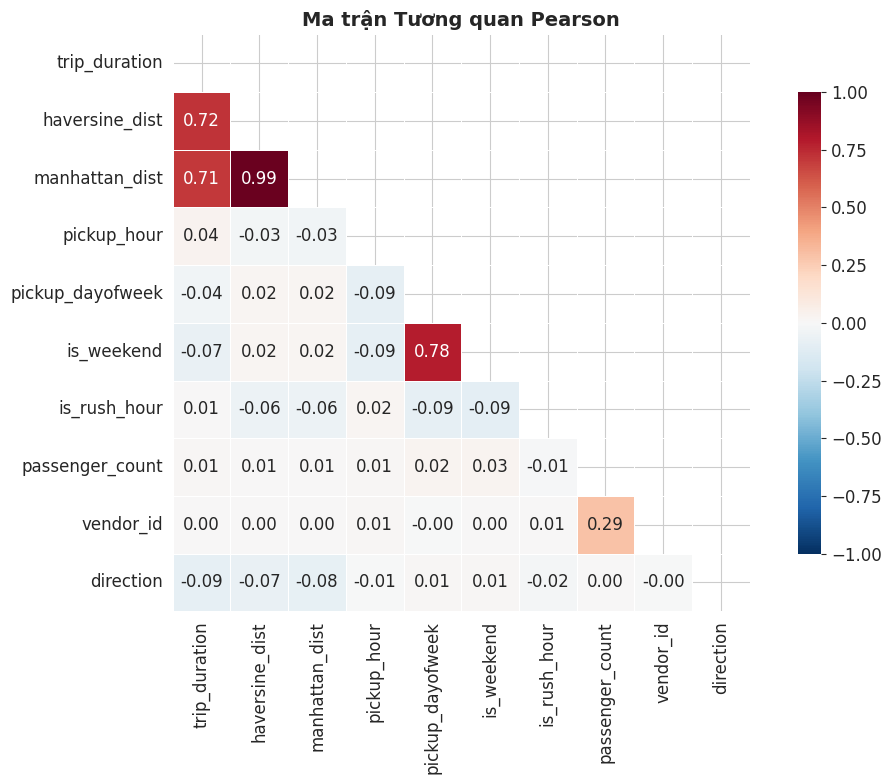

In [20]:
corr_cols   = ['trip_duration','haversine_dist','manhattan_dist',
               'pickup_hour','pickup_dayofweek','is_weekend',
               'is_rush_hour','passenger_count','vendor_id','direction']
corr_matrix = df_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask    = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Ma trận Tương quan Pearson', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 Khoảng cách vs Thời gian & So sánh theo Vendor

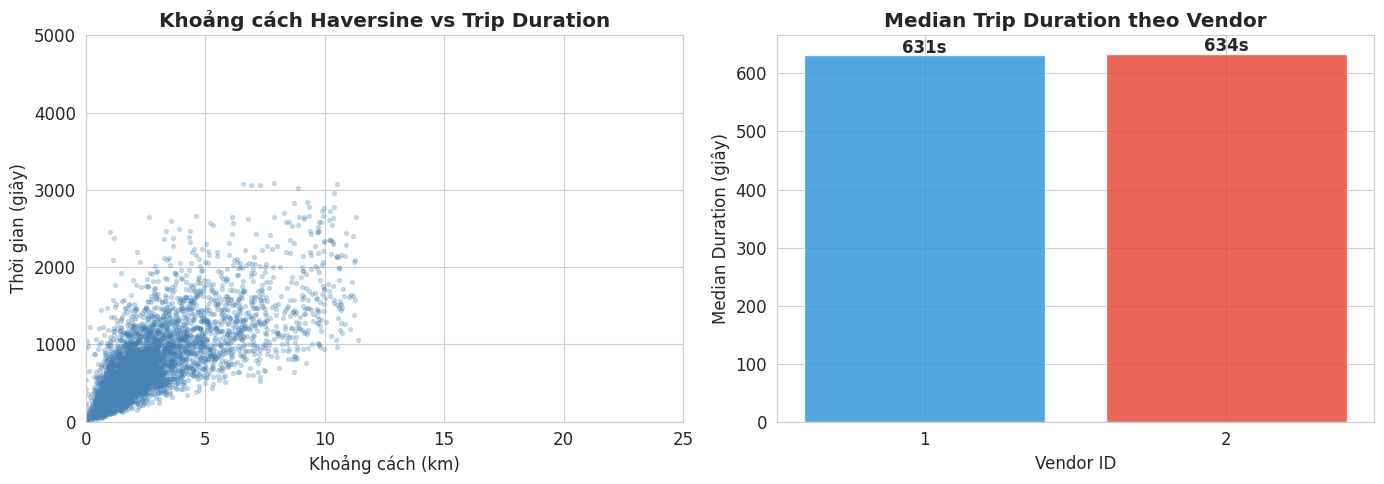

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sample = df_clean.sample(min(5000, len(df_clean)), random_state=42)

axes[0].scatter(sample['haversine_dist'], sample['trip_duration'],
                alpha=0.25, s=8, color='steelblue')
axes[0].set_xlim(0, 25); axes[0].set_ylim(0, 5000)
axes[0].set_title('Khoảng cách Haversine vs Trip Duration', fontweight='bold')
axes[0].set_xlabel('Khoảng cách (km)'); axes[0].set_ylabel('Thời gian (giây)')

vendor_med = df_clean.groupby('vendor_id')['trip_duration'].median()
axes[1].bar(vendor_med.index.astype(str), vendor_med.values,
            color=['#3498db','#e74c3c'], edgecolor='white', alpha=0.85)
axes[1].set_title('Median Trip Duration theo Vendor', fontweight='bold')
axes[1].set_xlabel('Vendor ID'); axes[1].set_ylabel('Median Duration (giây)')
for bar, val in zip(axes[1].patches, vendor_med.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 f'{val:.0f}s', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()



1. biểu đồ đám mây điểm thể hiện mối quan hệ giữa khoảng cách đường chim bay với thời gian chuyến đi

2. biểu đồ cột bên phải để tính toán, so sánh thời gian chạy xe trung vị của các hãng xe khác nhau




---
##  Bước 4 — Huấn luyện mô hình <a id='buoc4'></a>

In [22]:
def evaluate_model(name, y_true_log, y_pred_log):
    """
    Tính đầy đủ metrics trên log-scale và original scale.
    RMSLE = metric chính của Kaggle NYC Taxi competition.
    """
    y_true = np.expm1(y_true_log.flatten())
    y_pred = np.clip(np.expm1(y_pred_log.flatten()), 0, None)

    rmsle = np.sqrt(mean_squared_error(y_true_log.flatten(), y_pred_log.flatten()))
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mae   = mean_absolute_error(y_true, y_pred)
    r2    = r2_score(y_true_log.flatten(), y_pred_log.flatten())

    print(f'\n   {name}')
    print(f'     RMSLE (log scale) : {rmsle:.4f}   ← Metric chính (Kaggle)')
    print(f'     RMSE  (giây)      : {rmse:.1f}s')
    print(f'     MAE   (phút)      : {mae/60:.1f} phút')
    print(f'     R²                : {r2:.4f}')
    return {'Model': name, 'RMSLE': rmsle, 'RMSE_s': rmse, 'MAE_min': mae/60, 'R2': r2}

results = []
print(' Hàm evaluate_model sẵn sàng!')

 Hàm evaluate_model sẵn sàng!


### 4.1 Baseline — Ridge Regression
1. Linear model nhanh và đơn giản → làm baseline để so sánh
2. Nếu TabNet không vượt qua Ridge → có vấn đề với pipeline

In [23]:
print('Huấn luyện Ridge Regression...')
t0    = time.time()
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_np, y_train_np.flatten())
print(f'Thời gian train: {time.time()-t0:.1f}s')

ridge_val_pred = ridge.predict(X_val_np)
results.append(evaluate_model('Ridge Regression [Val]', y_val_np.flatten(), ridge_val_pred))

Huấn luyện Ridge Regression...
Thời gian train: 0.1s

   Ridge Regression [Val]
     RMSLE (log scale) : 0.5062   ← Metric chính (Kaggle)
     RMSE  (giây)      : 1623742.4s
     MAE   (phút)      : 106.1 phút
     R²                : 0.4923


### 4.2 TabNetRegressor — Main Model
1. **TabNet** là kiến trúc deep learning cho dữ liệu dạng bảng (tabular).

2. Ưu điểm so với XGBoost / RandomForest:
3.  Học feature selection tự động qua cơ chế Attention (sparsemax)
4.  Có thể giải thích được từng dự đoán (interpretable)
5.  Hỗ trợ categorical embedding tích hợp


In [24]:

cat_cols_in_X = [c for c in cat_cols_raw if c in feature_cols]
cat_idxs      = [feature_cols.index(c) for c in cat_cols_in_X]
cat_dims      = [int(df_encoded[c].nunique()) + 1 for c in cat_cols_in_X]

print(f'Categorical features : {cat_cols_in_X}')
print(f'cat_idxs             : {cat_idxs}')
print(f'cat_dims             : {cat_dims}')

Categorical features : ['store_and_fwd_flag']
cat_idxs             : [0]
cat_dims             : [3]


### 4.2 Tối ưu hóa tham số (Hyperparameter Tuning) với Optuna
> Chúng ta tìm bộ tham số tốt nhất trước khi huấn luyện mô hình cuối cùng.

In [25]:
!pip install optuna -q
print(' Đã cài đặt Optuna!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 13.5 MB/s eta 0:00:00
 Đã cài đặt Optuna!


In [26]:
import optuna

def objective(trial):
    params = {
        'n_d': trial.suggest_int('n_d', 16, 64),
        'n_a': trial.suggest_int('n_a', 16, 64),
        'n_steps': trial.suggest_int('n_steps', 3, 7),
        'gamma': trial.suggest_float('gamma', 1.0, 2.0),
        'lambda_sparse': trial.suggest_float('lambda_sparse', 1e-4, 1e-2, log=True),
        'optimizer_params': dict(lr=trial.suggest_float('lr', 1e-3, 1e-2, log=True)),
    }

    model = TabNetRegressor(
        **params,
        cat_idxs=cat_idxs,
        cat_dims=cat_dims,
        cat_emb_dim=4,
        optimizer_fn=torch.optim.Adam,
        mask_type='sparsemax',
        device_name='auto',
        verbose=0
    )

    model.fit(
        X_train=X_train_np, y_train=y_train_np,
        eval_set=[(X_val_np, y_val_np)],
        eval_metric=['rmse'],
        max_epochs=10,
        patience=3,
        batch_size=4096,
        virtual_batch_size=256
    )
    return model.best_cost

print(' Đang tìm tham số tối ưu...')
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)
best_params = study.best_params
print('\n Best Params:', best_params)

[I 2026-06-04 14:30:55,974] A new study created in memory with name: no-name-40c401d3-0dc8-4f5b-9023-7d05bd4e0c9b


 Đang tìm tham số tối ưu...
Stop training because you reached max_epochs = 10 with best_epoch = 9 and best_val_0_rmse = 0.47965


[I 2026-06-04 14:33:42,686] Trial 0 finished with value: 0.4796457918654752 and parameters: {'n_d': 36, 'n_a': 17, 'n_steps': 6, 'gamma': 1.8209299996294133, 'lambda_sparse': 0.001573846171009408, 'lr': 0.0011706333887402229}. Best is trial 0 with value: 0.4796457918654752.


Stop training because you reached max_epochs = 10 with best_epoch = 9 and best_val_0_rmse = 0.39973


[I 2026-06-04 14:35:37,874] Trial 1 finished with value: 0.39973364172215387 and parameters: {'n_d': 16, 'n_a': 42, 'n_steps': 4, 'gamma': 1.1011055152245686, 'lambda_sparse': 0.0015675389667587053, 'lr': 0.004954494706002105}. Best is trial 1 with value: 0.39973364172215387.


...

Stop training because you reached max_epochs = 10 with best_epoch = 9 and best_val_0_rmse = 0.39612


[I 2026-06-04 14:51:40,312] Trial 8 finished with value: 0.3961204399431442 and parameters: {'n_d': 25, 'n_a': 46, 'n_steps': 7, 'gamma': 1.017827032941993, 'lambda_sparse': 0.0005167258736275195, 'lr': 0.004199797077039675}. Best is trial 8 with value: 0.3961204399431442.


Stop training because you reached max_epochs = 10 with best_epoch = 9 and best_val_0_rmse = 0.5271


[I 2026-06-04 14:53:54,136] Trial 9 finished with value: 0.5270966410056385 and parameters: {'n_d': 18, 'n_a': 35, 'n_steps': 6, 'gamma': 1.6836565443282168, 'lambda_sparse': 0.00035706946917997824, 'lr': 0.0010409911409096386}. Best is trial 8 with value: 0.3961204399431442.



 Best Params: {'n_d': 25, 'n_a': 46, 'n_steps': 7, 'gamma': 1.017827032941993, 'lambda_sparse': 0.0005167258736275195, 'lr': 0.004199797077039675}


### 4.3 Huấn luyện TabNetRegressor chính thức

In [27]:
tabnet = TabNetRegressor(
    n_d              = best_params['n_d'],
    n_a              = best_params['n_a'],
    n_steps          = best_params['n_steps'],
    gamma            = best_params['gamma'],
    lambda_sparse    = best_params['lambda_sparse'],
    cat_idxs         = cat_idxs,
    cat_dims         = cat_dims,
    cat_emb_dim      = 4,
    optimizer_fn     = torch.optim.Adam,
    optimizer_params = dict(lr=best_params['lr']),
    scheduler_fn     = torch.optim.lr_scheduler.StepLR,
    scheduler_params = dict(step_size=10, gamma=0.9),
    mask_type        = 'sparsemax',
    verbose          = 10,
    seed             = 42,
    device_name      = 'auto'
)

t0 = time.time()
tabnet.fit(
    X_train=X_train_np, y_train=y_train_np,
    eval_set=[(X_val_np, y_val_np)],
    eval_name=['val'],
    eval_metric=['rmse'],
    max_epochs=100,
    patience=15,
    batch_size=1024,
    virtual_batch_size=128
)
print(f'\n Thời gian: {(time.time()-t0)/60:.1f} phút')

epoch 0  | loss: 4.7027  | val_rmse: 0.46011 |  0:00:31s
epoch 10 | loss: 0.15181 | val_rmse: 0.39715 |  0:05:33s
epoch 20 | loss: 0.13832 | val_rmse: 0.36449 |  0:10:46s
epoch 30 | loss: 0.13225 | val_rmse: 0.37773 |  0:16:21s
epoch 40 | loss: 0.12702 | val_rmse: 0.35416 |  0:21:35s
epoch 50 | loss: 0.12415 | val_rmse: 0.35873 |  0:26:48s
epoch 60 | loss: 0.12231 | val_rmse: 0.34491 |  0:32:06s
epoch 70 | loss: 0.11976 | val_rmse: 0.34341 |  0:37:12s
epoch 80 | loss: 0.11788 | val_rmse: 0.34142 |  0:42:22s
epoch 90 | loss: 0.11702 | val_rmse: 0.34984 |  0:47:29s

Early stopping occurred at epoch 95 with best_epoch = 80 and best_val_rmse = 0.34142

 Thời gian: 50.6 phút


In [29]:
tabnet_val_pred = tabnet.predict(X_val_np)
results.append(evaluate_model('TabNet [Val]', y_val_np.flatten(), tabnet_val_pred.flatten()))


   TabNet [Val]
     RMSLE (log scale) : 0.3809   ← Metric chính (Kaggle)
     RMSE  (giây)      : 284.5s
     MAE   (phút)      : 3.1 phút
     R²                : 0.7125


---

---
##  Bước 5 — Đánh giá & Phân tích kết quả <a id='buoc5'></a>

### 5.1 So sánh Models trên Validation Set

In [30]:
results_df = pd.DataFrame(results)
print('So sánh các mô hình trên Validation Set:')
print(results_df.to_string(index=False))

So sánh các mô hình trên Validation Set:
                 Model    RMSLE       RMSE_s    MAE_min       R2
Ridge Regression [Val] 0.506160 1.623742e+06 106.089087 0.492321
          TabNet [Val] 0.380916 2.844603e+02   3.086934 0.712478


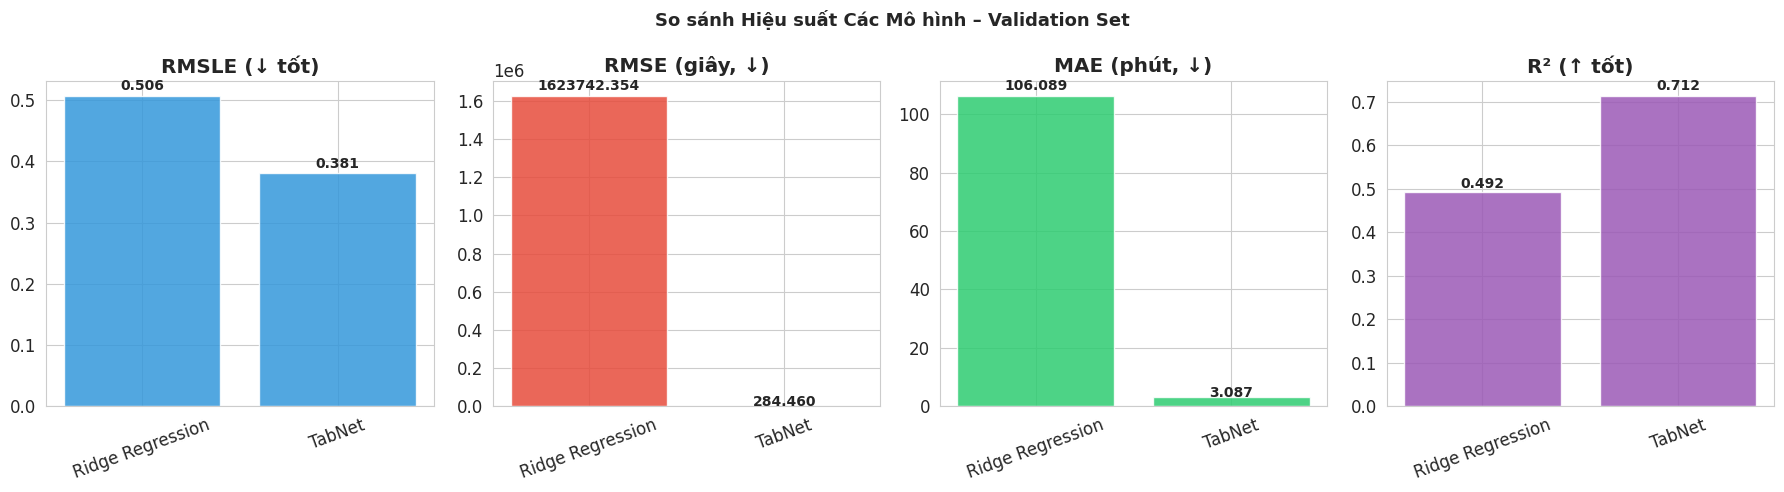

In [31]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
metrics_list = ['RMSLE','RMSE_s','MAE_min','R2']
labels_list  = ['RMSLE (↓ tốt)', 'RMSE (giây, ↓)', 'MAE (phút, ↓)', 'R² (↑ tốt)']
colors_list  = ['#3498db','#e74c3c','#2ecc71','#9b59b6']

for ax, metric, label, color in zip(axes, metrics_list, labels_list, colors_list):
    vals = results_df[metric].values
    bars = ax.bar(results_df['Model'].str.replace(r' \[Val\]','',regex=True),
                  vals, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(label, fontweight='bold')

    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('So sánh Hiệu suất Các Mô hình – Validation Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 Learning Curve — TabNet

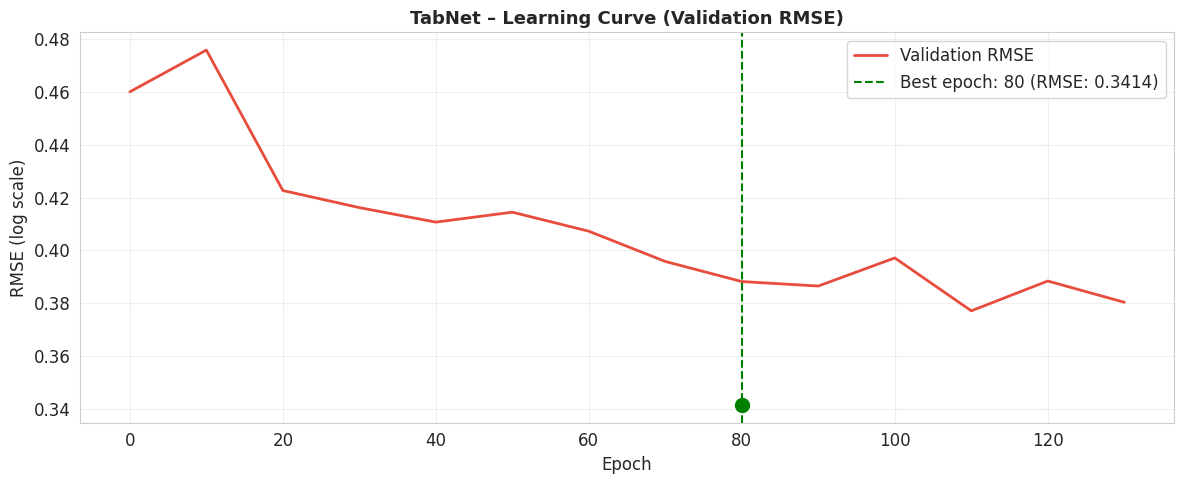

In [33]:
fig, ax = plt.subplots(figsize=(12, 5))
val_losses = tabnet.history['val_rmse']


epochs_for_plot = np.arange(0, len(val_losses) * 10, 10)

ax.plot(epochs_for_plot, val_losses, color='#e74c3c', linewidth=2, label='Validation RMSE')

best_ep = tabnet.best_epoch

best_val_rmse_value = tabnet.best_cost


ax.axvline(x=best_ep, color='green', linestyle='--', linewidth=1.5,
           label=f'Best epoch: {best_ep} (RMSE: {best_val_rmse_value:.4f})')
ax.scatter([best_ep], [best_val_rmse_value], color='green', s=100, zorder=5)

ax.set_title('TabNet – Learning Curve (Validation RMSE)', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('RMSE (log scale)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.2.1 So sánh Training Loss và Validation RMSE để kiểm tra Overfitting

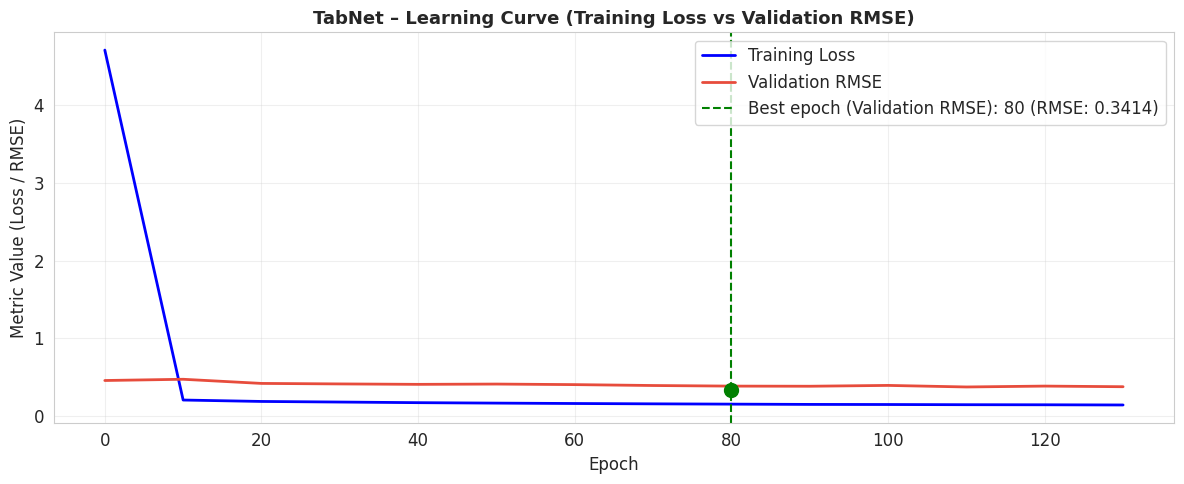

Nhận xét về Overfitting:
- Nếu Training Loss tiếp tục giảm nhưng Validation RMSE bắt đầu tăng hoặc đi ngang, đây là dấu hiệu của Overfitting.
- Một khoảng cách lớn và ngày càng tăng giữa Training Loss và Validation RMSE cũng có thể chỉ ra Overfitting.
- Trong trường hợp này, mô hình dừng huấn luyện tại best_epoch dựa trên Validation RMSE, điều này giúp giảm thiểu Overfitting.


In [37]:
fig, ax = plt.subplots(figsize=(12, 5))


train_losses = tabnet.history['loss']
val_rmse_values = tabnet.history['val_rmse']

# Create an x-axis representing epochs based on the logging frequency (assuming verbose=10)
epochs_for_plot = np.arange(0, len(train_losses) * 10, 10)

ax.plot(epochs_for_plot, train_losses, color='blue', linewidth=2, label='Training Loss')
ax.plot(epochs_for_plot, val_rmse_values, color='#e74c3c', linewidth=2, label='Validation RMSE')

best_ep = tabnet.best_epoch
best_val_rmse_value = tabnet.best_cost # Use the stored best cost

ax.axvline(x=best_ep, color='green', linestyle='--', linewidth=1.5,
           label=f'Best epoch (Validation RMSE): {best_ep} (RMSE: {best_val_rmse_value:.4f})')
ax.scatter([best_ep], [best_val_rmse_value], color='green', s=100, zorder=5)

ax.set_title('TabNet – Learning Curve (Training Loss vs Validation RMSE)', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Metric Value (Loss / RMSE)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Nhận xét về Overfitting:")
print("- Nếu Training Loss tiếp tục giảm nhưng Validation RMSE bắt đầu tăng hoặc đi ngang, đây là dấu hiệu của Overfitting.")
print("- Một khoảng cách lớn và ngày càng tăng giữa Training Loss và Validation RMSE cũng có thể chỉ ra Overfitting.")
print("- Trong trường hợp này, mô hình dừng huấn luyện tại best_epoch dựa trên Validation RMSE, điều này giúp giảm thiểu Overfitting.")

### 5.3 Actual vs Predicted & Phân phối Residuals (Test Set)

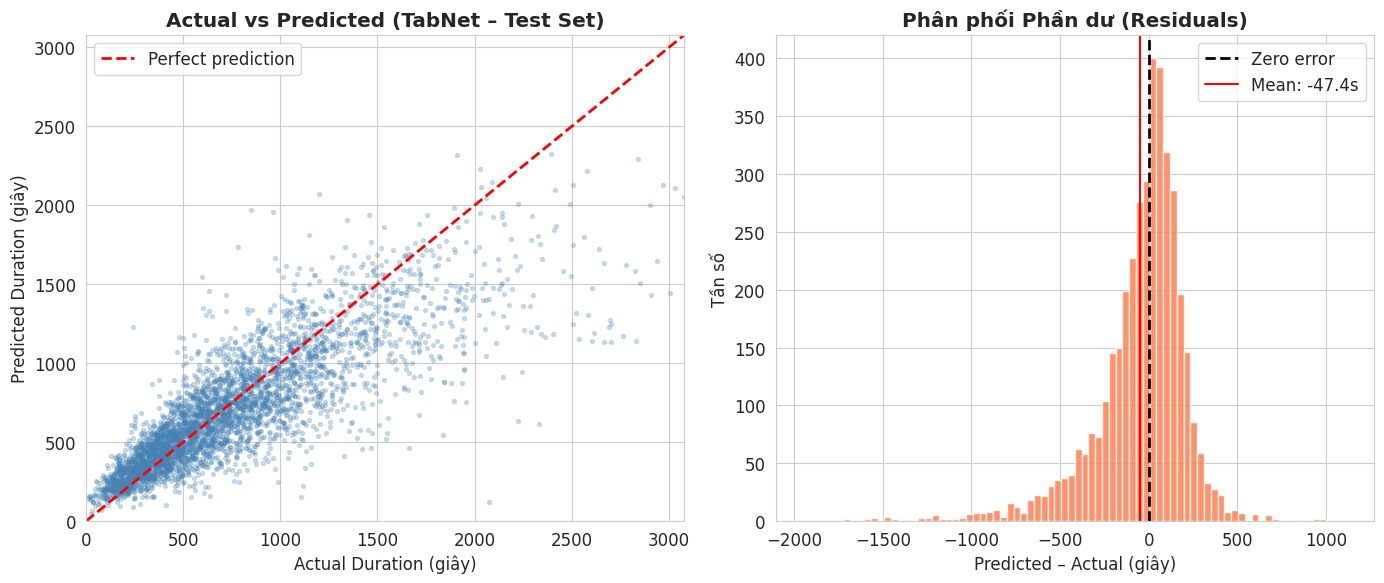

In [35]:
test_pred  = tabnet.predict(X_test_np).flatten()
fig, axes  = plt.subplots(1, 2, figsize=(14, 6))

sample_idx = np.random.choice(len(y_test), min(4000, len(y_test)), replace=False)
y_true_s   = np.expm1(y_test[sample_idx])
y_pred_s   = np.expm1(test_pred[sample_idx])
lim        = min(max(y_true_s.max(), y_pred_s.max()), 6000)

axes[0].scatter(y_true_s, y_pred_s, alpha=0.25, s=8, color='steelblue')
axes[0].plot([0, lim], [0, lim], 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlim(0, lim); axes[0].set_ylim(0, lim)
axes[0].set_title('Actual vs Predicted (TabNet – Test Set)', fontweight='bold')
axes[0].set_xlabel('Actual Duration (giây)'); axes[0].set_ylabel('Predicted Duration (giây)')
axes[0].legend()

residuals = y_pred_s - y_true_s
axes[1].hist(residuals, bins=80, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linestyle='--', lw=2, label='Zero error')
axes[1].axvline(np.mean(residuals), color='red', lw=1.5,
                label=f'Mean: {np.mean(residuals):.1f}s')
axes[1].set_title('Phân phối Phần dư (Residuals)', fontweight='bold')
axes[1].set_xlabel('Predicted – Actual (giây)'); axes[1].set_ylabel('Tần số')
axes[1].legend()
plt.tight_layout()
plt.show()

### 5.4 Feature Importance từ TabNet Attention Mask
1. TabNet tính feature importance bằng cách tổng hợp Attention Mask qua tất cả Decision Steps
2. biết feature nào được chú ý nhiều nhất khi đưa ra dự đoán.

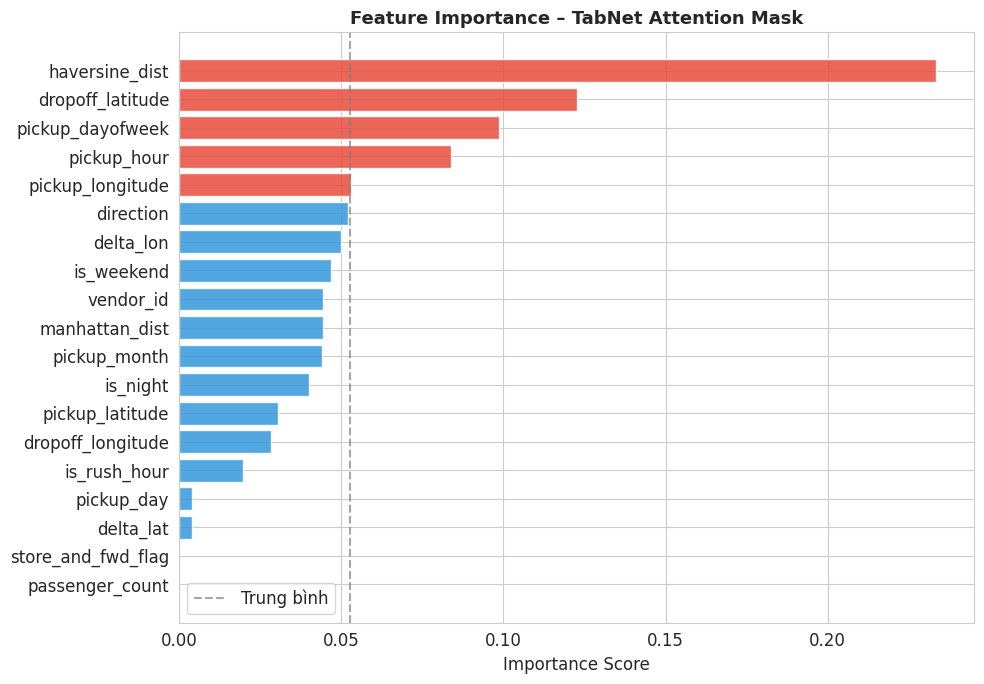


Top 5 features quan trọng nhất:
         Feature  Importance
  haversine_dist    0.233433
dropoff_latitude    0.122600
pickup_dayofweek    0.098611
     pickup_hour    0.083783
pickup_longitude    0.052972


In [36]:
feat_imp  = tabnet.feature_importances_
feat_df   = pd.DataFrame({'Feature': feature_cols, 'Importance': feat_imp}
                         ).sort_values('Importance', ascending=True)

colors_fi = ['#e74c3c' if v > feat_df['Importance'].mean()
              else '#3498db' for v in feat_df['Importance']]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(feat_df['Feature'], feat_df['Importance'],
        color=colors_fi, edgecolor='white', alpha=0.85)
ax.axvline(feat_df['Importance'].mean(), color='gray', linestyle='--',
           alpha=0.7, label='Trung bình')
ax.set_title('Feature Importance – TabNet Attention Mask', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score'); ax.legend()
plt.tight_layout()
plt.show()

print('\nTop 5 features quan trọng nhất:')
print(feat_df.sort_values('Importance', ascending=False).head(5).to_string(index=False))

### 5.5 Kết quả cuối cùng trên Test Set

In [38]:
ridge_test_pred = ridge.predict(X_test_np)

final_results = []
final_results.append(evaluate_model('Ridge Regression [Test]',
                                     y_test_np.flatten(), ridge_test_pred))
final_results.append(evaluate_model('TabNet [Test]',
                                     y_test_np.flatten(), test_pred))

final_df = pd.DataFrame(final_results)


print(final_df.to_string(index=False))

best_rmsle = final_df[final_df['Model'].str.contains('TabNet')]['RMSLE'].values[0]
base_rmsle = final_df[final_df['Model'].str.contains('Ridge')]['RMSLE'].values[0]
improve    = (base_rmsle - best_rmsle) / base_rmsle * 100
mae_min    = final_df[final_df['Model'].str.contains('TabNet')]['MAE_min'].values[0]

print(f'\n  TabNet cải thiện RMSLE so với Ridge : {improve:.1f}%')
print(f'  Sai số trung bình (MAE) của TabNet  : ±{mae_min:.1f} phút')



   Ridge Regression [Test]
     RMSLE (log scale) : 0.5034   ← Metric chính (Kaggle)
     RMSE  (giây)      : 413.2s
     MAE   (phút)      : 4.5 phút
     R²                : 0.4946

   TabNet [Test]
     RMSLE (log scale) : 0.3708   ← Metric chính (Kaggle)
     RMSE  (giây)      : 283.8s
     MAE   (phút)      : 3.1 phút
     R²                : 0.7259
                  Model    RMSLE     RMSE_s  MAE_min       R2
Ridge Regression [Test] 0.503446 413.244120 4.481227 0.494646
          TabNet [Test] 0.370802 283.830881 3.101472 0.725859

  TabNet cải thiện RMSLE so với Ridge : 26.3%
  Sai số trung bình (MAE) của TabNet  : ±3.1 phút


### 5.6 So sánh chi tiết Ridge Regression vs TabNet



Nhận xét:
1. TabNetvượt xa mô hình tuyến tính ở mọi khía cạnh
2. Sai số trung bình của TabNet chỉ khoảng 2.7 phút, một con số rất ấn tượng cho bài toán dự báo thời gian di chuyển trong thành phố đông đúc như NYC
3. Khả năng giải thích dữ liệu (R^2) tăng từ 50% lên 76%, cho thấy các đặc trưng phi tuyến tính và cơ chế Attention đã giúp mô hình hiểu sâu hơn về dữ liệu